# Let's write the Linear Regression algorithm from zero
In this notebook we write linear regression algorithm using NumPy, we will also make take a quick look at the mathematical foundations. Please note that any definition mathematical explanation here maybe vulgarised for simplicity. We will try to understand what we are working with, not formalise it.

1. Mathematical foundations of Linear Regression
2. Applications with NumPy
3. Normal Equation

## What is Linear Regression?

### Hypothesis

Linear Regression is a supervised learning algorithm. Let's breakdown the terminology. "Supervised" implies that we have a training set of $(X, y)$. Here $X$ is our inputs/features, we may have multiple dimension inputs, in that case $$X = 
\begin{pmatrix}
X_1 \\ X_2  \\  \vdots \\ X_n
\end{pmatrix}$$

Regression means we are trying to find a continuos function that will help us predict, given a new $X$, the new $y$. Finally, linear means we are looking for a linear function that will help us make predictions. This function is called "hypothesis" and denoted with $h$.

Let's say we have a dataset where $X$ has $n$ rows, so there are $n$ different values that affects our output $y$. In that case our hypothesis would look like this: $$h(X) = \vartheta_0 + \vartheta_1X_1  +\ldots + \vartheta_nX_n $$

You can confirm that $h$ is a linear function with parameters $\vartheta$. By the way, to be more precise $h$ is an affine function but we will call it a linear function for the ease :) 

### The idea: Minimize the cost

Now as we know what our hypothesis function $h$ would look like, we need to find the best values for $\vartheta$. In other terms we are trying to minimize our cost. For this we will use the famous **Least Squares Theorem**

Let's try to understand what Least Squares Theorem. Get a random $y_i$, this is our actual output. Our prediction $h(X_i)$ should be close to $y_i$. The error is $h(X_i)-y_i$. We will try to minimize square of error for all $X$, in more formal words we should minimize our cost function $J$. $$J(\vartheta) = \frac12 \sum_{i=0}^{m} (h(X_i)-y_i)^2 $$ We put $\frac12$ only for the ease at calculation of derivations. This wouldn't change the optimal parameters $\vartheta$. By the way, why are we taking it to square? There are various reasons. But most obvious answer: it is easier than dealing with absolute values. 

### How to minimize: Gradient Descent

At this point I can show you a lot of calculations with some partial derivatives. But I find it unnecessary for this notebook. I will just go through the idea of gradient descent and finally the formula. However, for those who are interested I highly recommend watching the relevant course of Stanford CS229, which was also the main source of this notebook. 

In gradient descent, we will get a random parameters vector $\vartheta$. Usually it's just zero $\vartheta = \vec0$. And then we are descending until we converge to the local optimal, which also happens to be a unique/global optimal

For the descend we will repeat the following formula until convergence $$\vartheta_j := \vartheta_j - \alpha \sum_{i=1}^{m} (h(X^{(i)})-y^{(i)}) X_j^{(i)} \quad \text{for } j = 0, 1, \ldots, n$$

In practice we often use the averaged version of this update, dividing the gradient by $m$, to make learning more stable and allow a more reasonable learning rate:

$$\vartheta_j := \vartheta_j - \frac{\alpha}{m} \sum_{i=1}^{m} (h(X^{(i)})-y^{(i)}) X_j^{(i)} \quad \text{for } j = 0, 1, \ldots, n$$

In vector form this is equivalent to:

$$\vartheta := \vartheta - \frac{\alpha}{m} X^T (h(X) - y)$$

Here I want to go through the notations again to not miss anything. $\vartheta_j$ is our parameter. At each iteration, we should apply this formula for each $\vartheta$ of our hypothesis function $h$. $\alpha$ is our learning rate, we will set it to an optimal value. If it's too small the convergence will take too many iterations. If it's too big then we can miss the minimum. The sum of error means we will go through each row our dataset. $X_j^{(i)}$ means the $j^{th}$ feature and row $i$.

Again, if this looked complicated I suggest you to take a look at CS229.


### Let's try

So now, I guess we understood the basic notions of linear regression. We'll now try to implement it. We will create a dummy dataset of house prices and try to fit our function to it.


In [161]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

# Create a dummy dataset of house prices
# Answer to the ultimate question of life, the universe, and everything
np.random.seed(42)

n_samples = 50

# Generate features
size = np.random.uniform(50, 300, n_samples)  # 50-300 sq meters
bedrooms = np.random.randint(1, 6, n_samples)  # 1-5 bedrooms

# Generate price based on a linear relationship with some noise
# Price in thousands of euros = 50 + 5*square_meters + 20*bedrooms + noise
price = 50 + 5 *size + 20 * bedrooms + np.random.normal(0, 20, n_samples)

# Create DataFrame
houses_df = pd.DataFrame({
    'size': size,
    'bedrooms': bedrooms,
    'price': price
})

print("House Prices Dataset:")
print(houses_df.head(10))
print(f"\nShape: {houses_df.shape}")

House Prices Dataset:
         size  bedrooms        price
0  143.635030         2   789.499892
1  287.678577         2  1544.077047
2  232.998485         4  1282.694912
3  199.664621         2  1094.980954
4   89.004660         2   507.408960
5   88.998630         4   569.377025
6   64.520903         4   451.408170
7  266.544036         1  1421.943658
8  200.278753         5  1187.279382
9  227.018144         5  1296.704513

Shape: (50, 3)


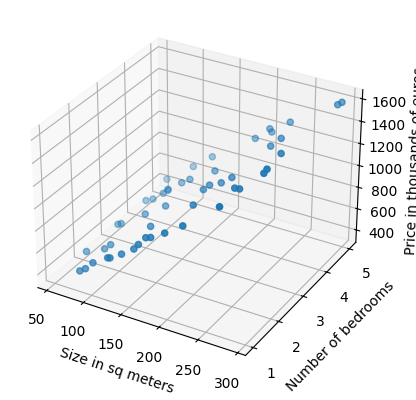

In [163]:
#Lets visualize
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.set_xlabel("Size in sq meters")
ax.set_ylabel("Number of bedrooms")
ax.set_zlabel("Price in thousands of euros")
ax.scatter(houses_df['size'], houses_df['bedrooms'], houses_df['price'])

plt.show()

### Feature scaling for better convergence
We normalize `size` and `bedrooms` before training so gradient descent can use a more reasonable learning rate and converge faster.

In [ ]:
theta = np.zeros(3)

# Prepare data: Add bias term (column of 1s) to features
size_mean, size_std = houses_df['size'].mean(), houses_df['size'].std()
bedrooms_mean, bedrooms_std = houses_df['bedrooms'].mean(), houses_df['bedrooms'].std()
size_norm = (houses_df['size'] - size_mean) / size_std
bedrooms_norm = (houses_df['bedrooms'] - bedrooms_mean) / bedrooms_std

X = np.column_stack([np.ones(n_samples), size_norm.values, bedrooms_norm.values])
y = houses_df['price'].values


def compute_cost(X, y, theta):
    m = len(y)
    h = X.dot(theta) 
    cost = (1 / (2 * m)) * np.sum((h - y) ** 2)
    return cost


def gradient_descent(X, y, theta, alpha, iterations):
    m = len(y)
    cost_history = []
    
    for iteration in range(iterations):
        h = X.dot(theta) 
        error = h - y    
        
        theta = theta - (alpha / m) * X.T.dot(error)
        
        cost = compute_cost(X, y, theta)

        if not np.isfinite(cost):
            print(f"Stopping at iteration {iteration+1}: cost is non-finite ({cost})")
            break

        cost_history.append(cost)
        
        if (iteration + 1) % 100 == 0:
            print(f"Iteration {iteration + 1}: Cost = {cost:.6f}")
    
    return theta, cost_history


alpha = 0.01  # learning rate
iterations = 1000
theta, cost_history = gradient_descent(X, y, theta, alpha, iterations)

print(f"\nLearned parameters θ:")
print(f"theta_0 (bias) = {theta[0]:.6f}")
print(f"theta_1 (size coefficient) = {theta[1]:.6f}")
print(f"theta_2 (bedrooms coefficient) = {theta[2]:.6f}")
if len(cost_history) > 0:
    print(f"\nFinal cost: {cost_history[-1]:.6f}")
else:
    print("\nNo cost history.")

Iteration 100: Cost = 64842.066132
Iteration 200: Cost = 8857.189230
Iteration 300: Cost = 1316.238505
Iteration 400: Cost = 300.282336
Iteration 500: Cost = 163.376738
Iteration 600: Cost = 144.923660
Iteration 700: Cost = 142.435823
Iteration 800: Cost = 142.100328
Iteration 900: Cost = 142.055074
Iteration 1000: Cost = 142.048968

Learned parameters θ:
theta_0 (bias) = 911.126284
theta_1 (size coefficient) = 363.268781
theta_2 (bedrooms coefficient) = 33.281801

Final cost: 142.048968


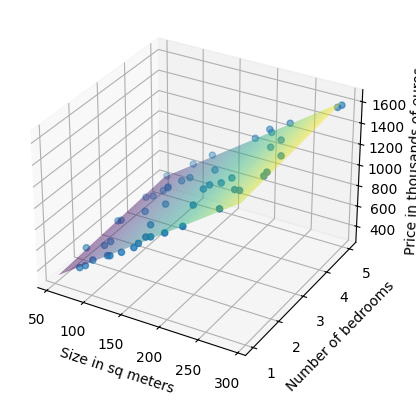

In [165]:
x_ax = np.linspace(houses_df['size'].min(), houses_df['size'].max())
y_ax = np.linspace(houses_df['bedrooms'].min(), houses_df['bedrooms'].max())
X_grid, Y_grid = np.meshgrid(x_ax, y_ax)

X_grid_norm = (X_grid - size_mean) / size_std
Y_grid_norm = (Y_grid - bedrooms_mean) / bedrooms_std
H = theta[0] + theta[1] * X_grid_norm + theta[2] * Y_grid_norm

fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.set_xlabel("Size in sq meters")
ax.set_ylabel("Number of bedrooms")
ax.set_zlabel("Price in thousands of euros")
ax.scatter(houses_df['size'], houses_df['bedrooms'], houses_df['price'])
ax.plot_surface(X_grid, Y_grid, H, alpha=0.5, cmap='viridis')

plt.show()

### Normal Equation

Instead of iterating with gradient descent, we can directly compute the best parameters by solving the equation that makes the derivative of the cost zero.

For linear regression:
- hypothesis: $h(X) = X \vartheta $
- cost: $J(\vartheta) = \frac{1}{2m} \|X\vartheta - y\|^2 $

Set the gradient to zero and solve:
$\vartheta = (X^T X)^{-1} X^T y $

This gives the optimal parameters in one shot, without choosing a learning rate or running iterations. It works well for small feature sets, but needs $(X^T X)$ to be invertible and is slower for large numbers of features.


Let's test it.

In [166]:
XTX = X.T.dot(X)
XTy = X.T.dot(y)

theta_normal = np.linalg.inv(XTX).dot(XTy)

print("Parameters from Normal Equation:")
print(f"theta_0 (bias) = {theta_normal[0]:.6f}")
print(f"theta_1 (size coefficient) = {theta_normal[1]:.6f}")
print(f"theta_2 (bedrooms coefficient) = {theta_normal[2]:.6f}")

print("\nComparison with Gradient Descent:")
print(f"Difference in theta_0: {abs(theta[0] - theta_normal[0]):.6f}")
print(f"Difference in theta_1: {abs(theta[1] - theta_normal[1]):.6f}")
print(f"Difference in theta_2: {abs(theta[2] - theta_normal[2]):.6f}")

# Verify by computing cost with normal equation parameters
cost_normal = compute_cost(X, y, theta_normal)
print(f"\nCost with Normal Equation: {cost_normal:.6f}")
print(f"Cost with Gradient Descent: {cost_history[-1]:.6f}")

Parameters from Normal Equation:
theta_0 (bias) = 911.165620
theta_1 (size coefficient) = 363.287895
theta_2 (bedrooms coefficient) = 33.281951

Comparison with Gradient Descent:
Difference in theta_0: 0.039336
Difference in theta_1: 0.019114
Difference in theta_2: 0.000150

Cost with Normal Equation: 142.048015
Cost with Gradient Descent: 142.048968


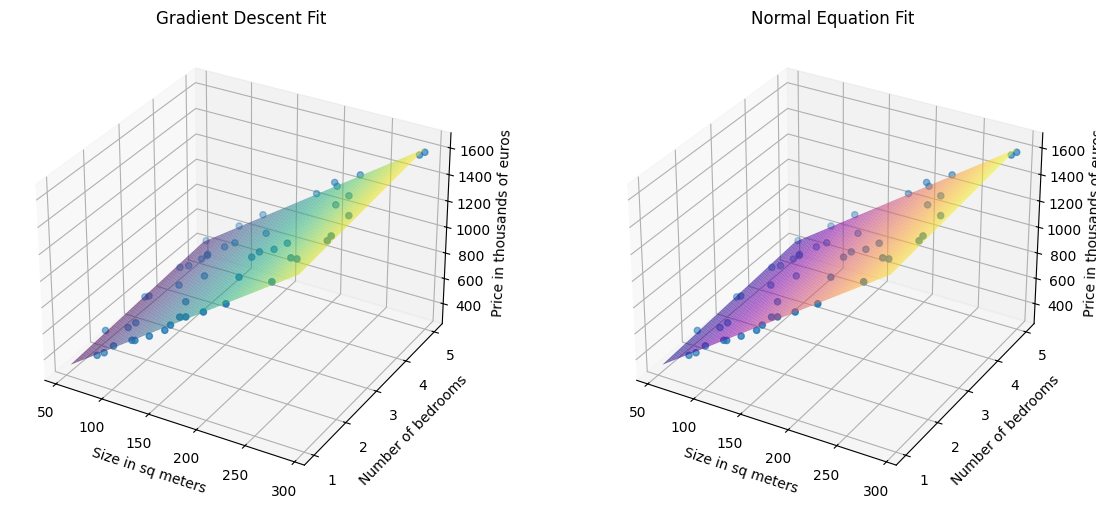

In [167]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), subplot_kw={'projection': '3d'})

H_normal = theta_normal[0] + theta_normal[1] * X_grid_norm + theta_normal[2] * Y_grid_norm

y_ticks = np.arange(int(houses_df['bedrooms'].min()), int(houses_df['bedrooms'].max()) + 1, 1)

ax1 = axes[0]
ax1.set_title("Gradient Descent Fit")
ax1.set_xlabel("Size in sq meters")
ax1.set_ylabel("Number of bedrooms")
ax1.set_zlabel("Price in thousands of euros")
ax1.set_yticks(y_ticks)
ax1.scatter(houses_df['size'], houses_df['bedrooms'], houses_df['price'])
ax1.plot_surface(X_grid, Y_grid, H, alpha=0.6, cmap='viridis')

ax2 = axes[1]
ax2.set_title("Normal Equation Fit")
ax2.set_xlabel("Size in sq meters")
ax2.set_ylabel("Number of bedrooms")
ax2.set_zlabel("Price in thousands of euros")
ax2.set_yticks(y_ticks)
ax2.scatter(houses_df['size'], houses_df['bedrooms'], houses_df['price'])
ax2.plot_surface(X_grid, Y_grid, H_normal, alpha=0.6, cmap='plasma')

plt.show()
